# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Healthcare Patient Analysis Dataset](https://www.kaggle.com/datasets/abbas829/healthcare-patient-analytics-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	


# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('healthcare_patient_analytics_seaborn.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40


## last Five row

In [4]:
df.tail()

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
4995,4996,2022-07-28 03:00:00,60+,Male,North,Cardiology,Observation,Routine,2.0,52402.0,54.0,0.54
4996,4997,2022-07-28 04:00:00,18-30,Female,North,Neurology,Surgery,Emergency,3.6,63973.0,58.0,0.39
4997,4998,2022-07-28 05:00:00,31-45,Male,North,Cardiology,Observation,Routine,6.2,38100.0,89.0,0.25
4998,4999,2022-07-28 06:00:00,46-60,Female,West,Neurology,Surgery,Emergency,4.0,66931.0,66.0,0.28
4999,5000,2022-07-28 07:00:00,31-45,Male,East,General Medicine,Observation,Emergency,4.1,19833.0,67.0,0.13


## Shape of our dataset

In [5]:
df.shape

(5000, 12)

## List out all columns

In [6]:
df.columns

Index(['patient_id', 'visit_date', 'age_group', 'gender', 'region',
       'department', 'treatment_type', 'visit_type', 'length_of_stay_days',
       'treatment_cost', 'recovery_score', 'readmission_risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

patient_id               int64
visit_date              object
age_group               object
gender                  object
region                  object
department              object
treatment_type          object
visit_type              object
length_of_stay_days    float64
treatment_cost         float64
recovery_score         float64
readmission_risk       float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   visit_date           5000 non-null   object 
 2   age_group            5000 non-null   object 
 3   gender               5000 non-null   object 
 4   region               5000 non-null   object 
 5   department           5000 non-null   object 
 6   treatment_type       5000 non-null   object 
 7   visit_type           5000 non-null   object 
 8   length_of_stay_days  5000 non-null   float64
 9   treatment_cost       5000 non-null   float64
 10  recovery_score       5000 non-null   float64
 11  readmission_risk     5000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 468.9+ KB


## Check Null Value

In [9]:
df.isnull().sum()

patient_id             0
visit_date             0
age_group              0
gender                 0
region                 0
department             0
treatment_type         0
visit_type             0
length_of_stay_days    0
treatment_cost         0
recovery_score         0
readmission_risk       0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,patient_id,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,4.059660,54915.471800,74.718800,0.280966
std,1443.520003,1.928847,19481.160487,11.870481,0.157178
min,1.000000,0.000000,746.000000,33.000000,0.010000
25%,1250.750000,2.700000,41244.750000,67.000000,0.160000
50%,2500.500000,4.000000,55123.500000,75.000000,0.260000
75%,3750.250000,5.400000,68012.000000,83.000000,0.380000
max,5000.000000,11.900000,119307.000000,100.000000,0.840000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

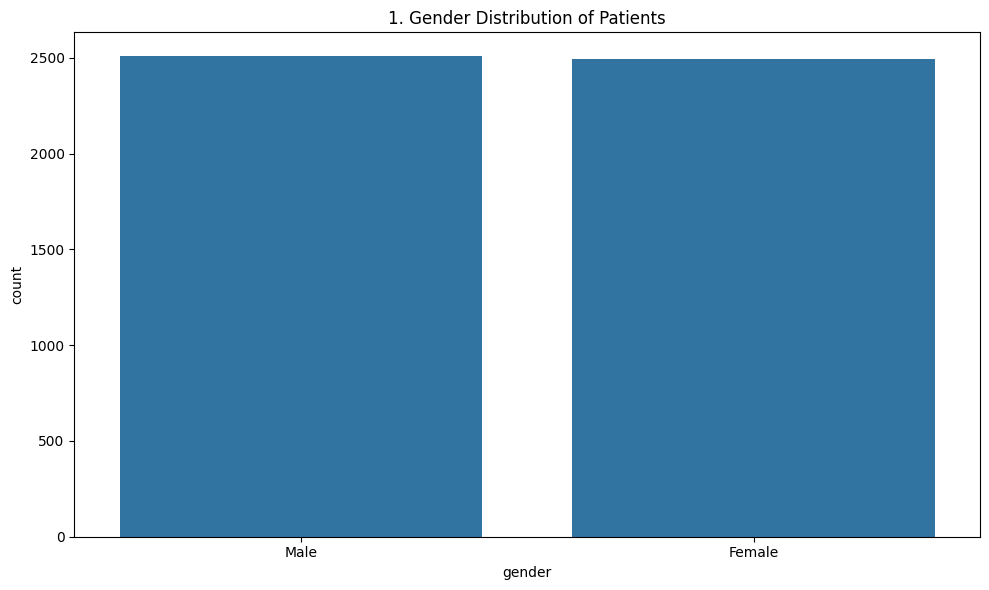

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender')
plt.title(f'{plot_no}. Gender Distribution of Patients')
show_fig()
plot_no += 1

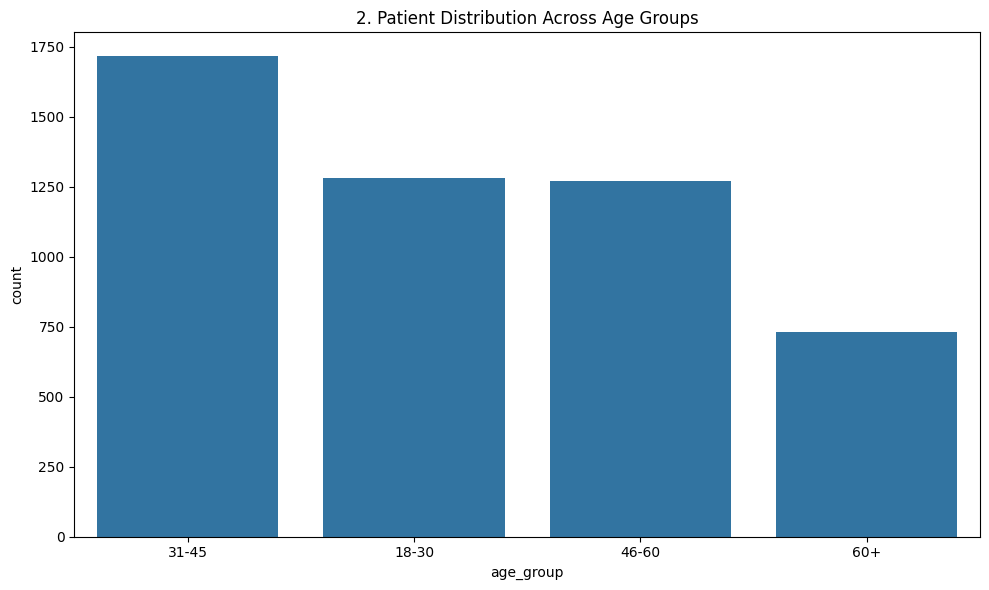

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='age_group', order=df['age_group'].value_counts().index)
plt.title(f'{plot_no}. Patient Distribution Across Age Groups')
show_fig()
plot_no += 1

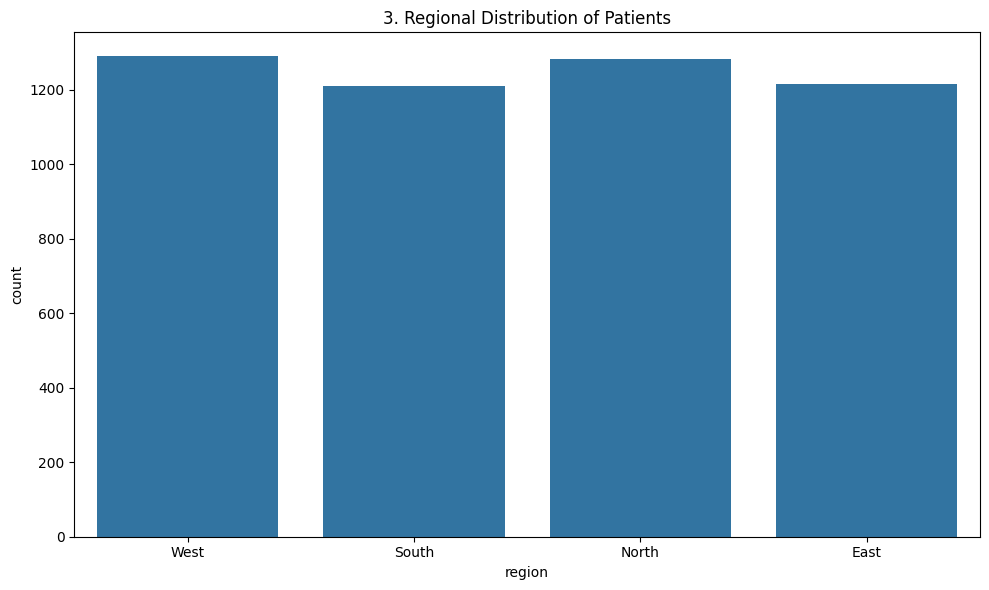

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='region')
plt.title(f'{plot_no}. Regional Distribution of Patients')
show_fig()
plot_no += 1

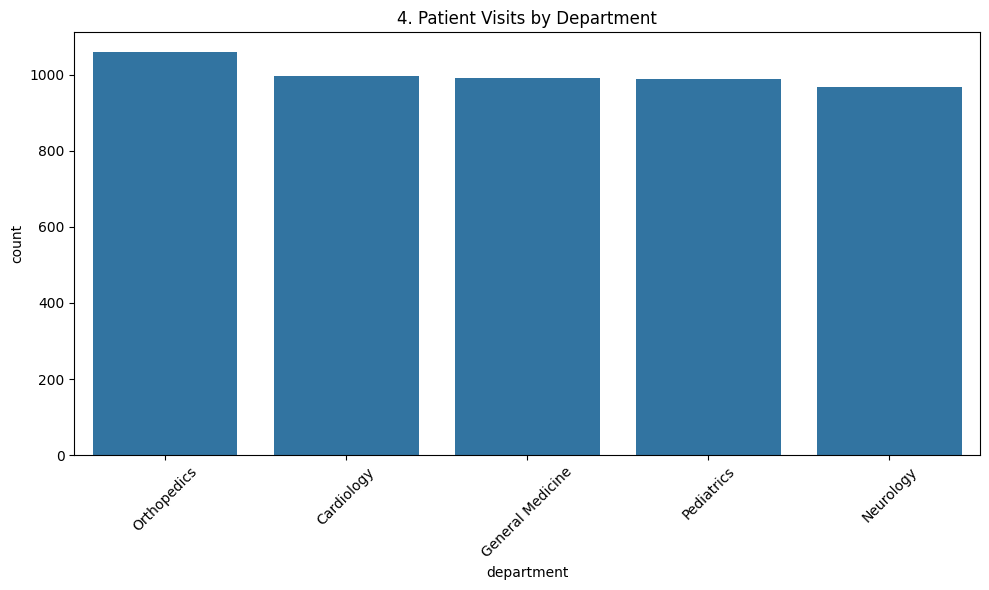

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='department', order=df['department'].value_counts().index)
plt.title(f'{plot_no}. Patient Visits by Department')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

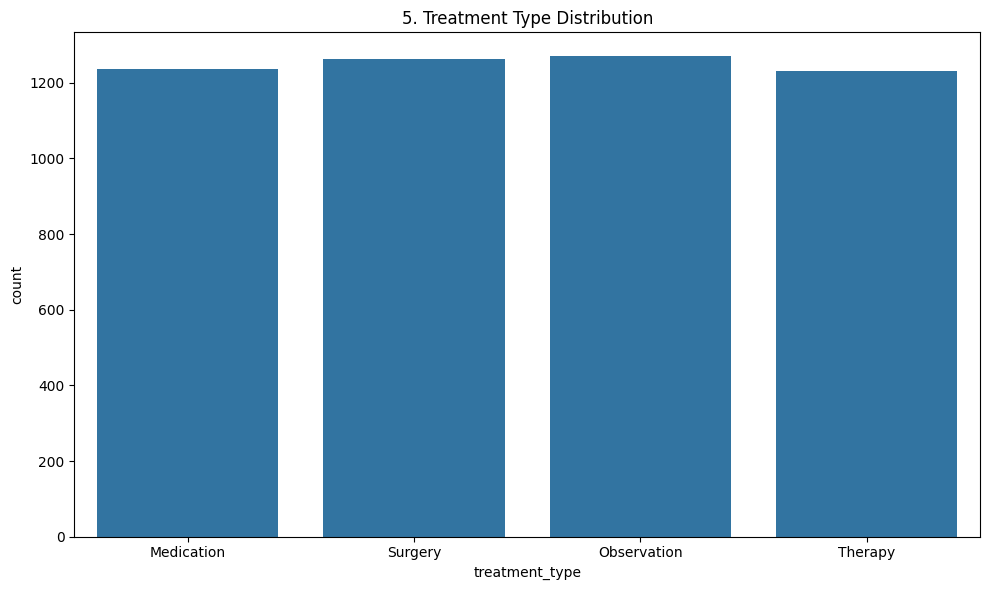

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='treatment_type')
plt.title(f'{plot_no}. Treatment Type Distribution')
show_fig()
plot_no += 1

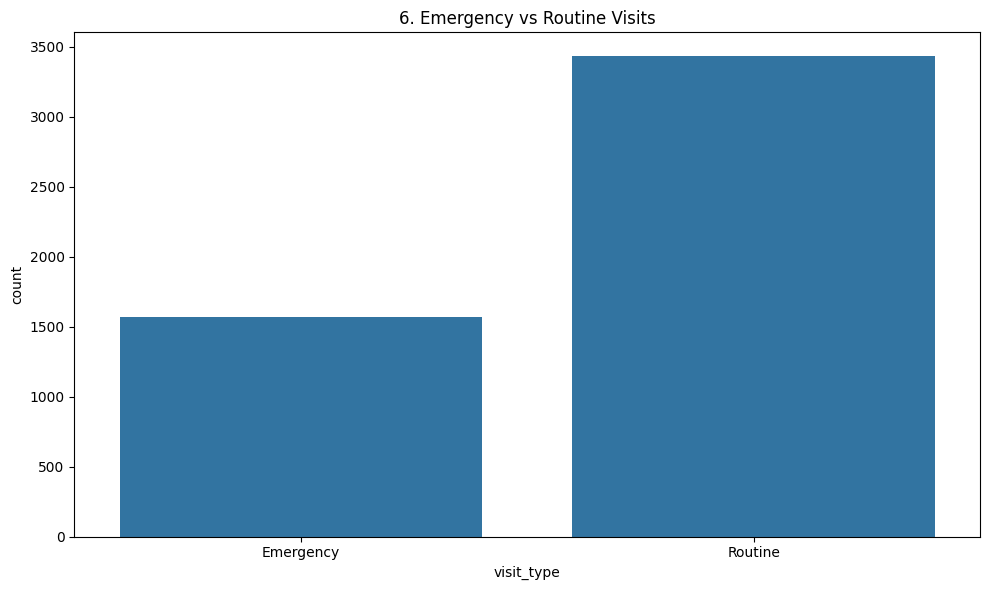

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='visit_type')
plt.title(f'{plot_no}. Emergency vs Routine Visits')
show_fig()
plot_no += 1

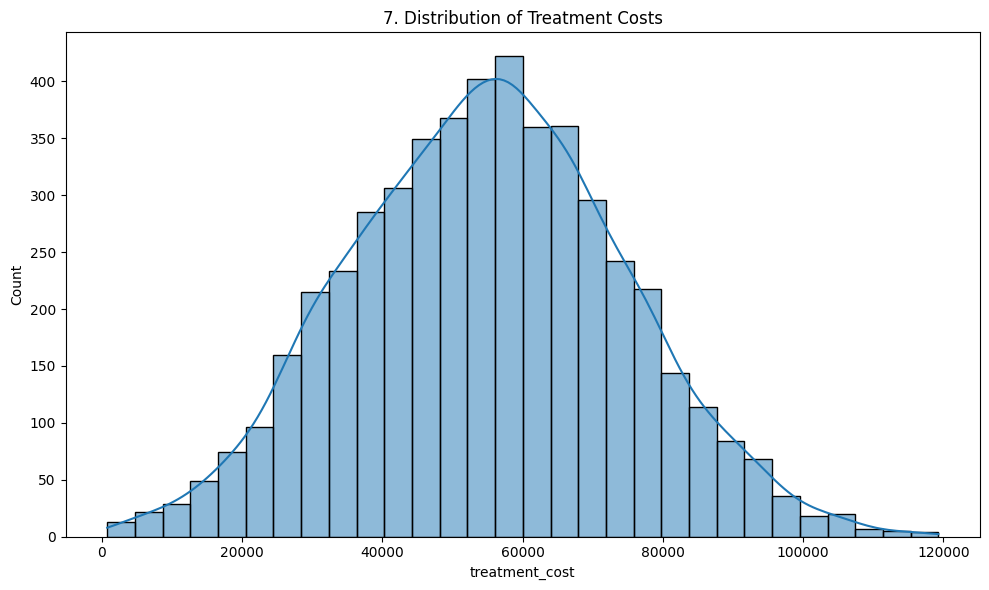

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['treatment_cost'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Treatment Costs')
show_fig()
plot_no += 1

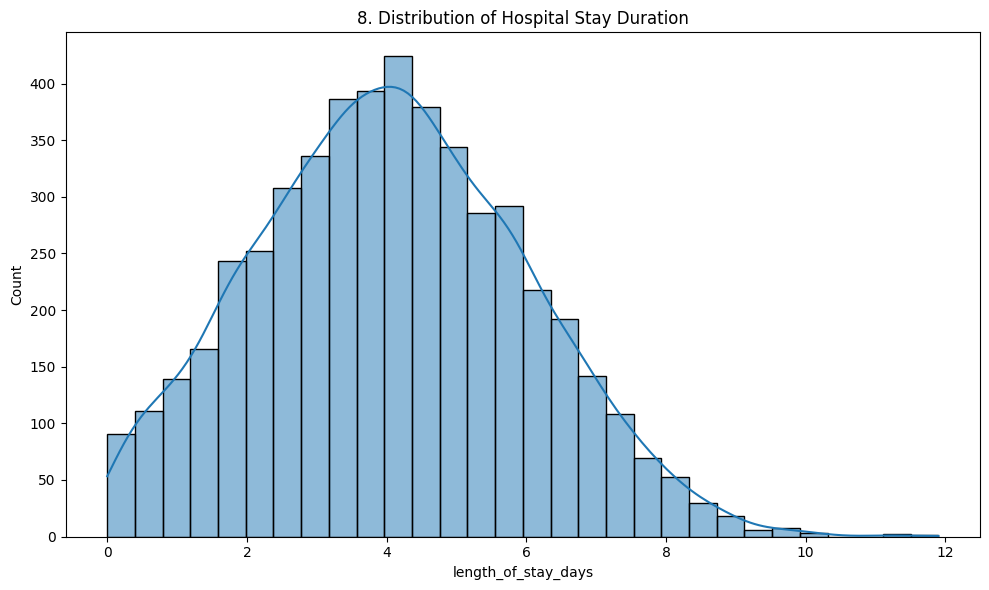

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['length_of_stay_days'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Hospital Stay Duration')
show_fig()
plot_no += 1

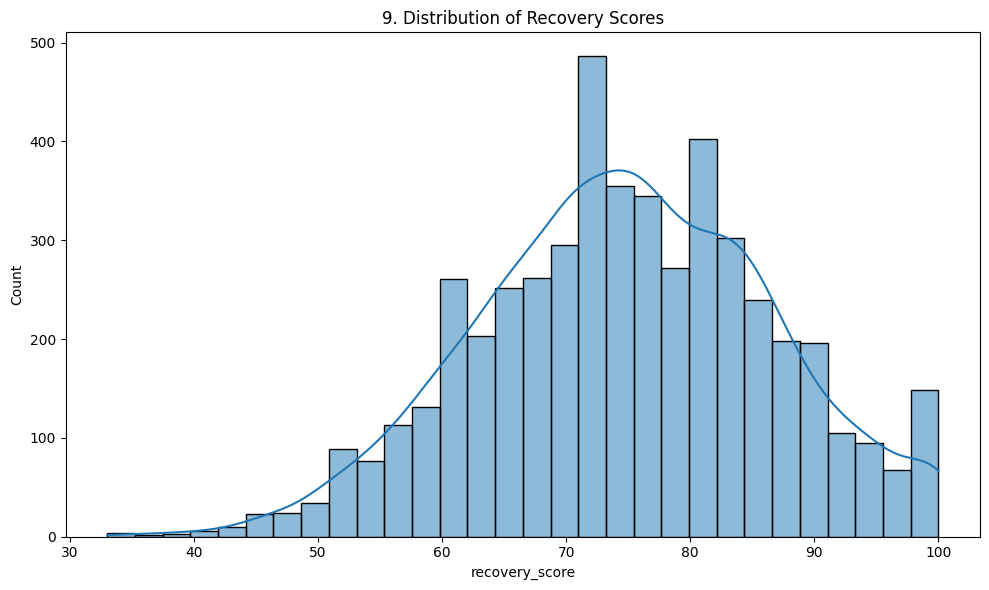

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['recovery_score'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Recovery Scores')
show_fig()
plot_no += 1

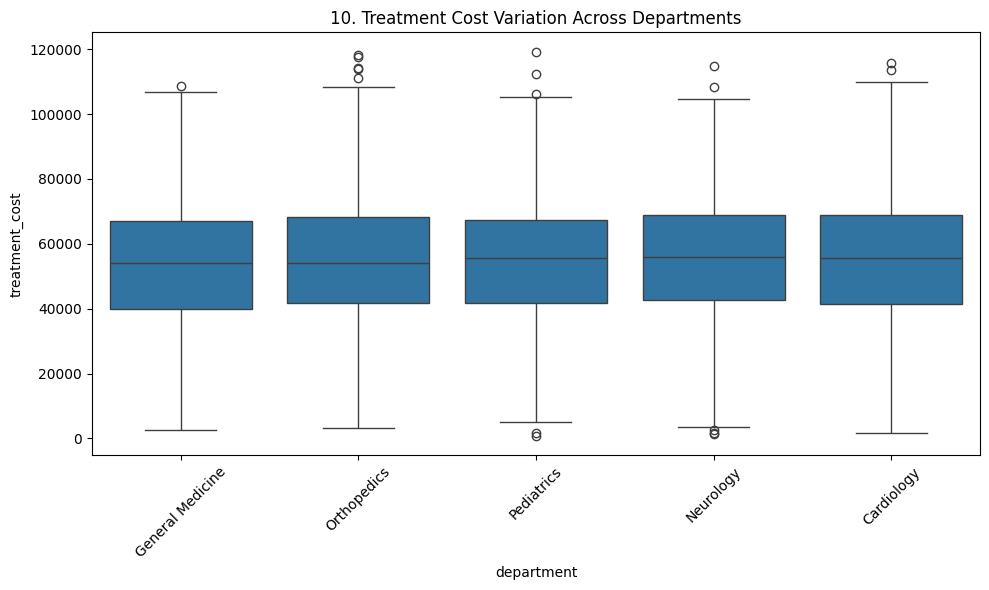

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='department', y='treatment_cost')
plt.title(f'{plot_no}. Treatment Cost Variation Across Departments')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

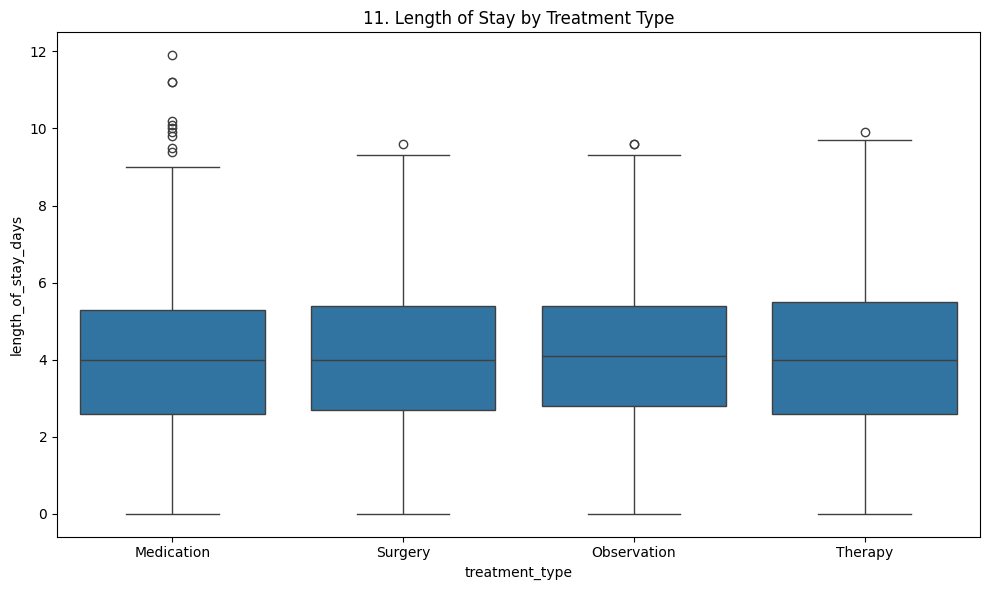

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='treatment_type', y='length_of_stay_days')
plt.title(f'{plot_no}. Length of Stay by Treatment Type')
show_fig()
plot_no += 1

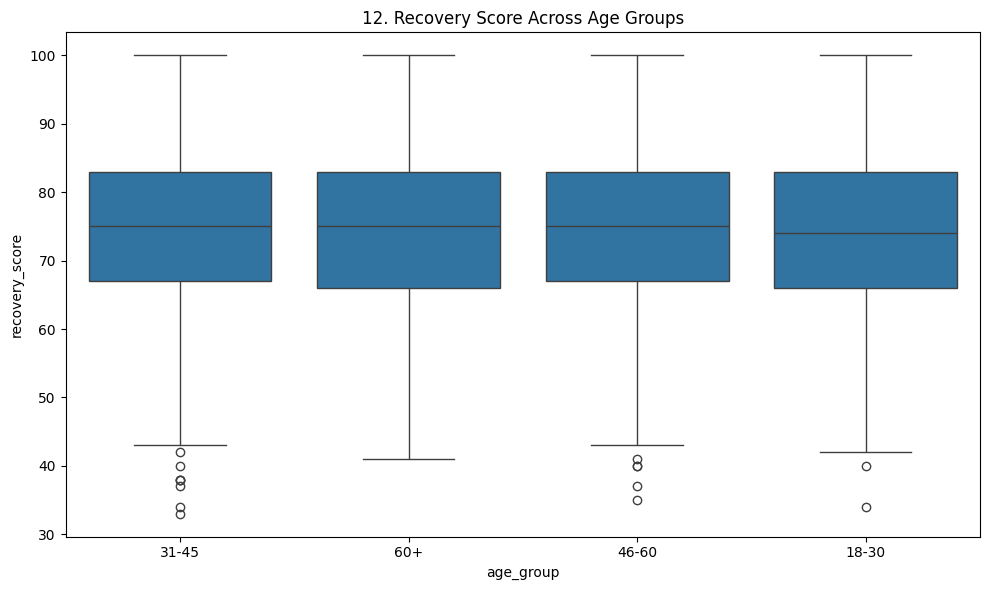

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='age_group', y='recovery_score')
plt.title(f'{plot_no}. Recovery Score Across Age Groups')
show_fig()
plot_no += 1

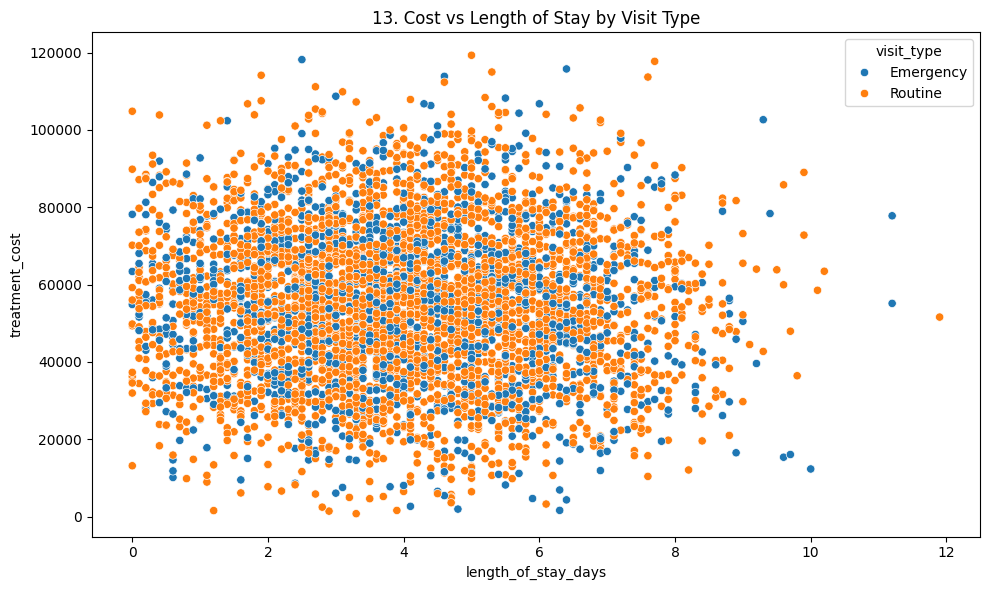

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='length_of_stay_days', y='treatment_cost', hue='visit_type')
plt.title(f'{plot_no}. Cost vs Length of Stay by Visit Type')
show_fig()
plot_no += 1

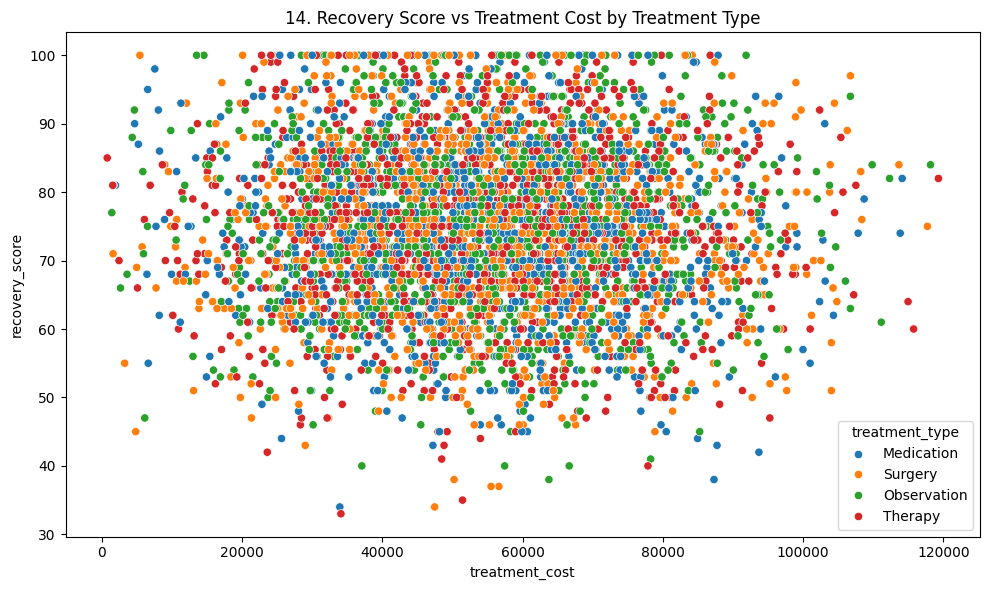

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='treatment_cost', y='recovery_score', hue='treatment_type')
plt.title(f'{plot_no}. Recovery Score vs Treatment Cost by Treatment Type')
show_fig()
plot_no += 1

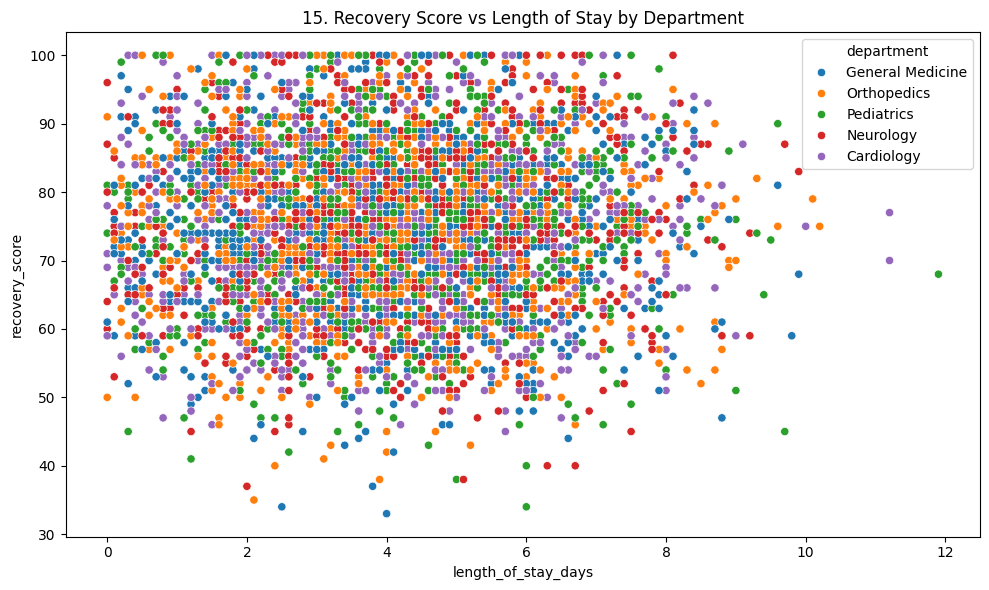

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='length_of_stay_days', y='recovery_score', hue='department')
plt.title(f'{plot_no}. Recovery Score vs Length of Stay by Department')
show_fig()
plot_no += 1

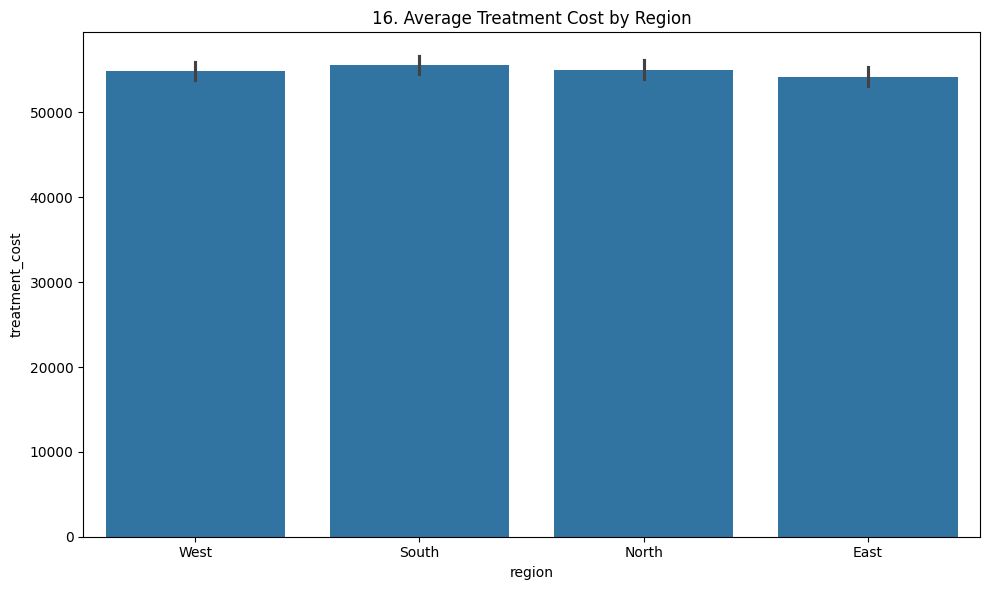

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='region', y='treatment_cost', estimator=np.mean)
plt.title(f'{plot_no}. Average Treatment Cost by Region')
show_fig()
plot_no += 1

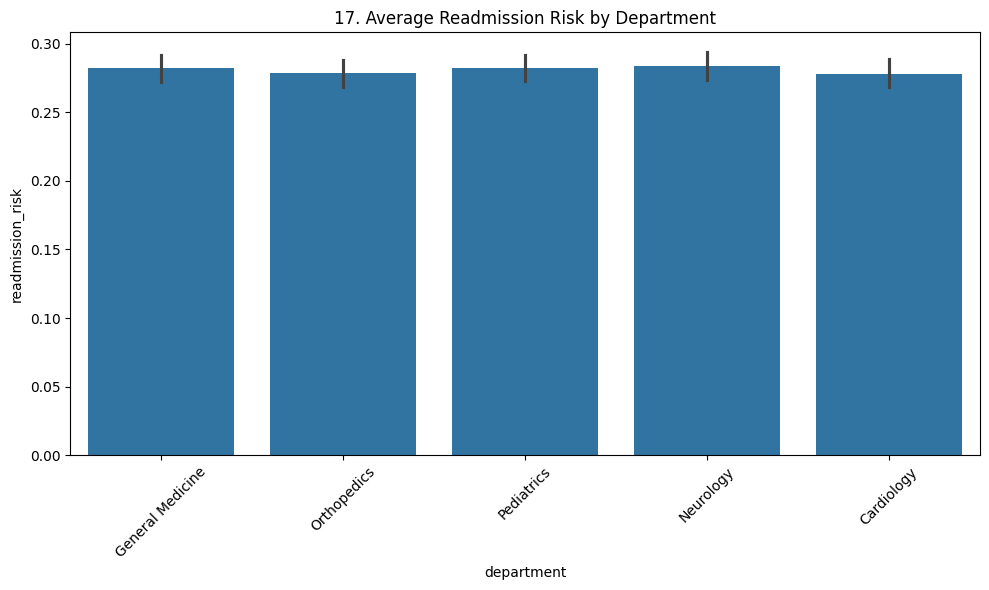

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='department', y='readmission_risk', estimator=np.mean)
plt.title(f'{plot_no}. Average Readmission Risk by Department')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

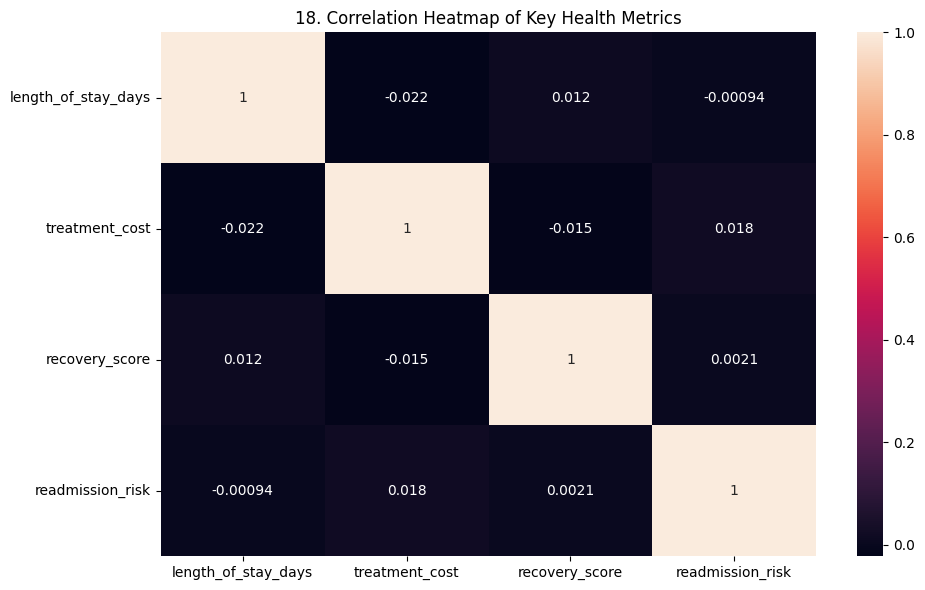

In [30]:
fig = plt.figure(figsize=(10,6))
corr = df[['length_of_stay_days','treatment_cost','recovery_score','readmission_risk']].corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Key Health Metrics')
show_fig()
plot_no += 1

# Model Training

## copy dataframe

In [31]:
data = df.copy()

## convert date into useful features

In [32]:
data['visit_date'] = pd.to_datetime(data['visit_date'])
data['visit_hour'] = data['visit_date'].dt.hour
data['visit_day'] = data['visit_date'].dt.day
data['visit_month'] = data['visit_date'].dt.month

## label encoding

In [33]:
cat_cols = ['age_group','gender','region','department','treatment_type','visit_type']
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

## feature engineering (important boost)

In [34]:
data['cost_per_day'] = data['treatment_cost'] / (data['length_of_stay_days'] + 1)
data['severity'] = data['length_of_stay_days'] * data['readmission_risk']

## define X and y

In [35]:
X = data.drop(columns=['patient_id','visit_date','readmission_risk'])
y = (data['readmission_risk'] > data['readmission_risk'].median()).astype(int)

## split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scaling

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train powerful model

In [38]:
model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## predictions

In [39]:
y_pred = model.predict(X_test)

## accuracy

In [40]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.986


## confusion matrix

<Figure size 1000x600 with 0 Axes>

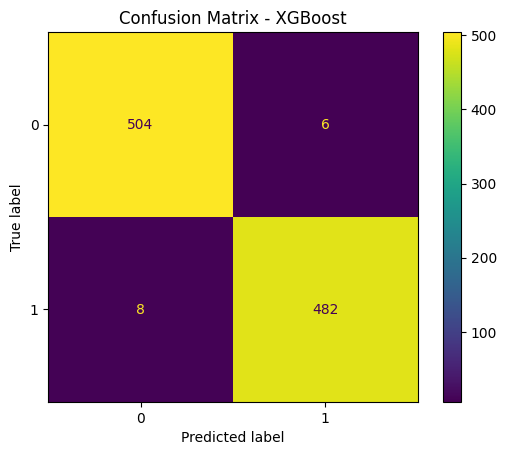

In [41]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()